<a href="https://colab.research.google.com/github/GiorgiKarazanashvili/cs666student/blob/main/CS666_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

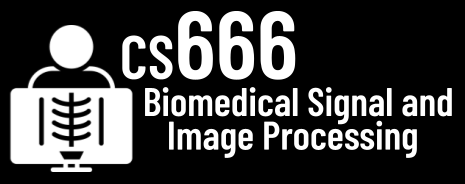

# Assignment 1

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


**Task 1** (5 pts): Install the BioSPPY library with the following code.

In [2]:
!pip install biosppy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 4.1 MB/s eta 0:00:00


**Task 2** (10 pts): Download a sample ecg dataset from https://cs666.org/data/ecg.txt and upload it to this colab. The following code loads the dataset. Note: this might fail with an import error, but should be an easy fix :)

In [7]:
!wget https://cs666.org/data/ecg.txt
!pip install peakutils

--2026-02-19 03:15:32--  https://cs666.org/data/ecg.txt
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105085 (103K) [text/plain]
Saving to: ‘ecg.txt.2’

ecg.txt.2           100%[===================>] 102.62K  --.-KB/s    in 0.01s   

2026-02-19 03:15:32 (6.97 MB/s) - ‘ecg.txt.2’ saved [105085/105085]



In [8]:
from biosppy import storage
signal, metadata = storage.load_txt('ecg.txt')

**Task 3** (10 pts): Figure out the sampling rate for this data and how many seconds it lasts.

In [18]:
print(f'{metadata} \n {len(signal)}')
print(f'seconds: {15000/1000}')

{'sampling_rate': 1000.0, 'resolution': 12, 'labels': ['ECG']} 
 15000
seconds: 15.0


In [19]:
SAMPLING_RATE = 1000.0 ### TODO!
SECONDS = 15.0 ### TODO!

**Task 4** (15 pts): Process the signal with BioSPPY using the `ecg.ecg` method.

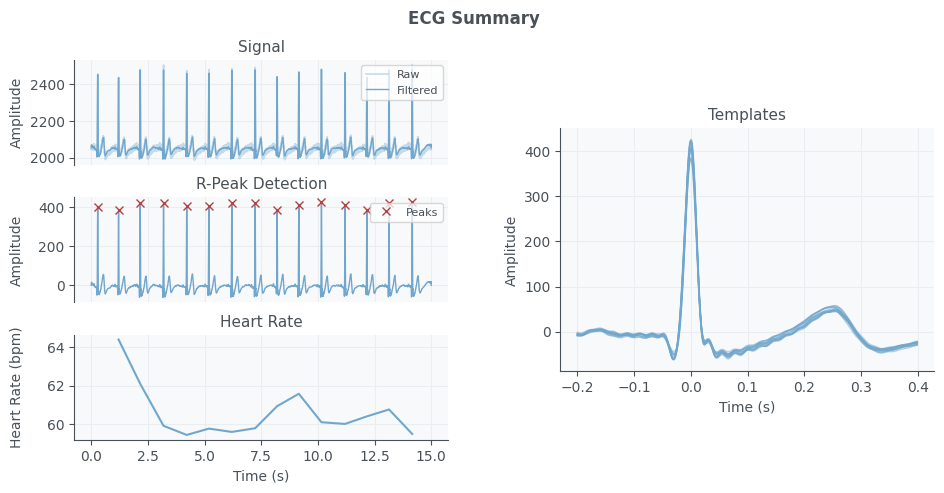

In [29]:
### TODO
from biosppy.signals import ecg
processed = ecg.ecg(signal=signal, sampling_rate=SAMPLING_RATE, show=True)

**Task 5** (10 pts): Plot the first 3 seconds of the unfiltered signal and then the filtered signal. Can you spot the P, Q, R, S, T waves?

#####As shown below, the filtered and unfiltered versions have clearly identifiable P, Q, R, S and T waves. Though the filtered version does make it easier to identify and looks smoother.

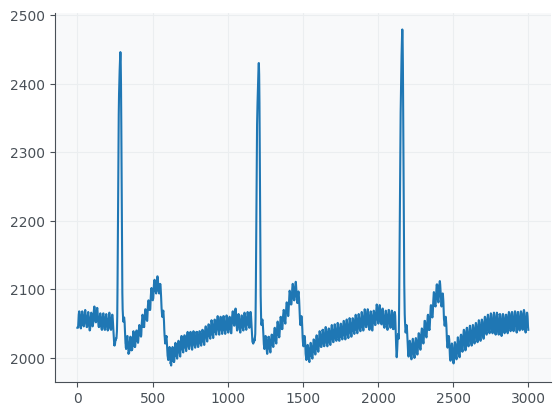

In [35]:
### TODO plot unfiltered signal
first_3 = int(3*SAMPLING_RATE)
plt.figure()
plt.plot(signal[:first_3])

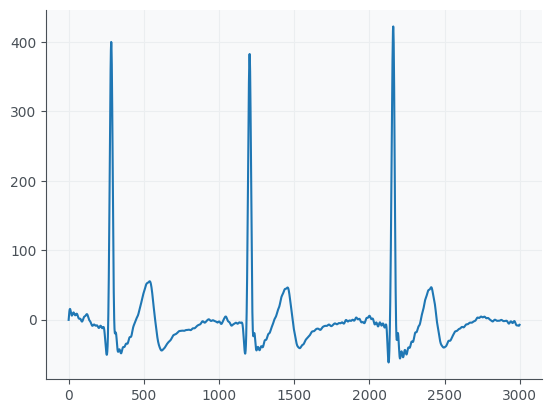

In [38]:
### TODO plot filtered signal
plt.figure()
plt.plot(processed['filtered'][:first_3])

**Task 6** (15 pts): Please plot the whole filtered signal and mark the r-peaks with vertical lines based on the ecg.ecg output. You can use `plt.axvline(x = 100, color = 'r', ls=':')` to create a red, dashed vertical line at position 100. Please label the x-axis as 'time [s]'.

Text(0.5, 0, 'time [s]')

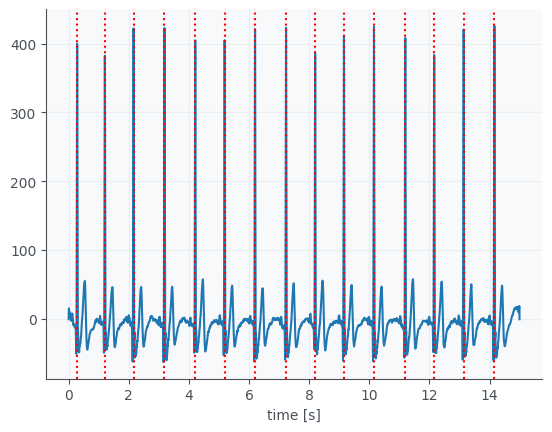

In [49]:
### TODO
plt.figure()
time = np.arange(len(processed['filtered'])) / SAMPLING_RATE
plt.plot(time, processed["filtered"])

for rpeak in processed['rpeaks']:
  plt.axvline(x=rpeak/SAMPLING_RATE, color='r', ls=':')

plt.xlabel('time [s]')

**Task 7** (5 pts): Let's install the NeuroKit2 library.

In [50]:
!pip install neurokit2
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 12.3 MB/s eta 0:00:00


**Task 8** (20 pts): Detect P Q S T Peaks using Neurokit.

In [ ]:
# We know the R spikes now but what about P Q S T waves?
# TODO Can you use nk.ecg_delineate to detect them in the unfiltred signal?
# Hint: Look at the tutorial: https://neuropsychology.github.io/NeuroKit/examples/ecg_delineate/ecg_delineate.html
# Hint 2: The plot will have blue, orange, green, and red circles :)
# Hint 3: rpeaks were detected above from biosppy's ecg.ecg method

#####The peaks are detected, but harder to read.

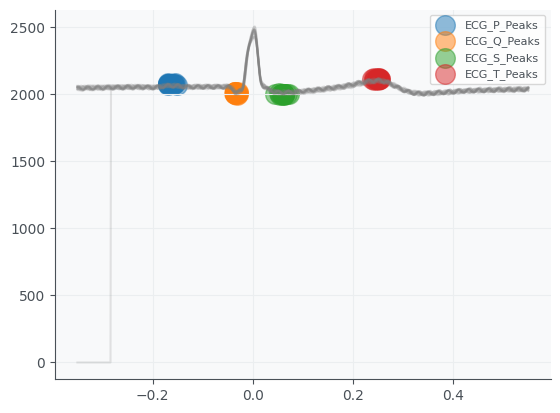

In [56]:
# TODO Does the detection work well?
_, waves_peak = nk.ecg_delineate(signal,
                                 processed['rpeaks'],
                                 sampling_rate=SAMPLING_RATE,
                                 method="peak",
                                 show=True,
                                 show_type='peaks')

**Task 9** (10 pts): Use the sleepecg library to find the R Peaks.

In [ ]:
# We have the R spikes/peaks now from Biosppy from above but there is another
# library called sleepecg.
# TODO Please install it and run the rpeak detection!
# Docs: https://sleepecg.readthedocs.io/en/stable/

#####they both found 15 peaks with MSE of 0.2 the libraries are very similar

In [57]:
!pip install sleepecg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 5.7 MB/s eta 0:00:00


In [67]:
# TODO Do Biosppy and sleepecg give different rpeaks? Please calculate the MSE!
import sleepecg

sleep_rpeaks = sleepecg.detect_heartbeats(signal, fs=SAMPLING_RATE)

#MSE
#min_len = min(len(processed['rpeaks']), len(sleep_rpeaks))
print(len(processed['rpeaks']))
print(len(sleep_rpeaks))
mse = np.mean((processed['rpeaks']- sleep_rpeaks) ** 2)
print(mse)


15
15
0.2


**Bonus Task** (33 pts): Detect P Q S T Peaks for the full signal before and after filtering.

In [ ]:
# TODO As above use the nk.ecg_delineate function to detect peaks for the whole signal

In [ ]:
# TODO Let's filter the signal and see if the detection improves.
# Hint: You can use nk.signal_filter to define a bandpass.
# Hint 2: Which lowcut and highcut frequencies work well? Play with it :)
# Hint 3: You don't need to re-calculate the rpeaks since they are pretty accurate in general.

In [ ]:
# Finally, run the delineation on the filtered signal from BioSPPY.

In [ ]:
# TODO Which one works the best?

In [ ]:
#
# Great job!!
#
#  , ; ,   .-'"""'-.   , ; ,
#  \\|/  .'         '.  \|//
#   \-;-/   ()   ()   \-;-/
#   // ;               ; \\
#  //__; :.         .; ;__\\
# `-----\'.'-.....-'.'/-----'
#        '.'.-.-,_.'.'
#jgs       '(  (..-'
#            '-'
#